# Cognifyz Technologies — Data Analysis Internship
## Level 2 Tasks

**Tasks Covered:**
- Task 1: Restaurant Ratings
- Task 2: Cuisine Combination
- Task 3: Geographic Analysis
- Task 4: Restaurant Chains

---

## 📦 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Libraries imported successfully!')

Libraries imported successfully!


## 📂 Load the Dataset

In [3]:
df = pd.read_csv('Dataset_.csv', encoding='utf-8-sig')
print(f'Dataset shape: {df.shape}')
print(f'Total Restaurants: {len(df)}')
df.head()

Dataset shape: (9551, 21)
Total Restaurants: 9551


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


---
## ✅ Task 1 — Restaurant Ratings
> Analyze distribution of aggregate ratings, find most common rating range, and calculate average votes.

In [4]:
rated = df[df['Aggregate rating'] > 0].copy()
bins = [0, 1, 2, 3, 4, 5]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5']
rated['Rating Range'] = pd.cut(rated['Aggregate rating'], bins=bins, labels=labels)
rating_range_counts = rated['Rating Range'].value_counts().sort_index()
most_common_range = rating_range_counts.idxmax()
avg_votes = df['Votes'].mean().round(2)

print('=== Restaurant Ratings Analysis ===')
print(f'Total rated restaurants     : {len(rated)}')
print(f'Average rating              : {rated["Aggregate rating"].mean():.2f}')
print(f'Most common rating range    : {most_common_range}')
print(f'Average votes per restaurant: {avg_votes}')
print()
print('--- Rating Range Distribution ---')
for rng, count in rating_range_counts.items():
    pct = count / len(rated) * 100
    print(f'  {rng} stars : {count} restaurants ({pct:.1f}%)')

=== Restaurant Ratings Analysis ===
Total rated restaurants     : 7403
Average rating              : 3.44
Most common rating range    : 3-4
Average votes per restaurant: 156.91

--- Rating Range Distribution ---
  0-1 stars : 0 restaurants (0.0%)
  1-2 stars : 10 restaurants (0.1%)
  2-3 stars : 1891 restaurants (25.5%)
  3-4 stars : 4388 restaurants (59.3%)
  4-5 stars : 1114 restaurants (15.0%)


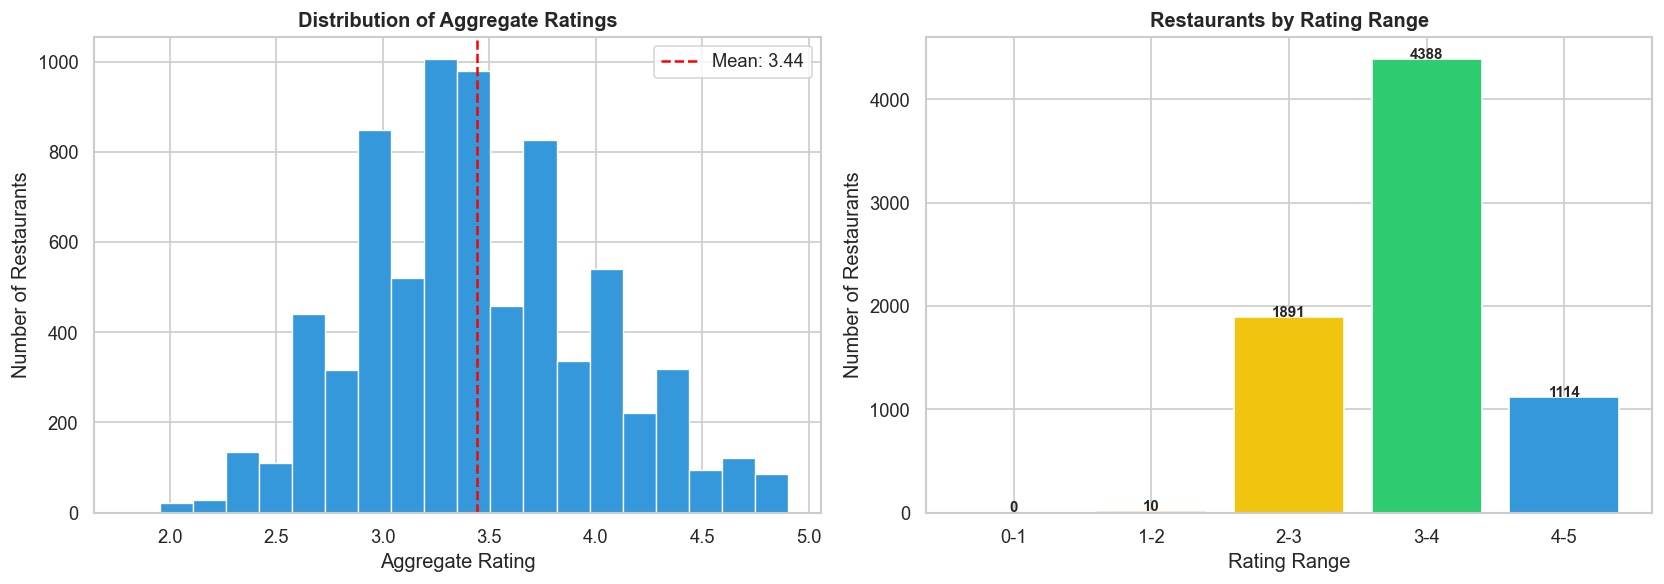

Chart saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(rated['Aggregate rating'], bins=20, color='#3498db', edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribution of Aggregate Ratings', fontweight='bold')
axes[0].set_xlabel('Aggregate Rating')
axes[0].set_ylabel('Number of Restaurants')
axes[0].axvline(rated['Aggregate rating'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {rated["Aggregate rating"].mean():.2f}')
axes[0].legend()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
bars = axes[1].bar(rating_range_counts.index, rating_range_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Restaurants by Rating Range', fontweight='bold')
axes[1].set_xlabel('Rating Range')
axes[1].set_ylabel('Number of Restaurants')
for bar, val in zip(bars, rating_range_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_L2_ratings.png', bbox_inches='tight')
plt.show()
print('Chart saved!')

### 🔍 Task 1 Insights
- Most restaurants fall in the 3-4 star rating range.
- Very few restaurants have ratings below 2 stars.
- Average votes show good customer engagement with reviews.

---
## ✅ Task 2 — Cuisine Combination
> Identify most common cuisine combinations and check if certain combinations have higher ratings.

In [6]:
multi = df[df['Cuisines'].str.contains(',', na=False)].copy()

def normalize_combo(cuisine_str):
    parts = [c.strip() for c in cuisine_str.split(',')]
    return ', '.join(sorted(parts))

multi['Cuisine Combo'] = multi['Cuisines'].apply(normalize_combo)
top_combos = multi['Cuisine Combo'].value_counts().head(10)

print('=== Top 10 Most Common Cuisine Combinations ===')
for i, (combo, count) in enumerate(top_combos.items(), 1):
    print(f'{i:2}. {combo} — {count} restaurants')

combo_ratings = multi[multi['Aggregate rating'] > 0].groupby('Cuisine Combo')['Aggregate rating'].mean()
top_rated_combos = combo_ratings.sort_values(ascending=False).head(10)
print()
print('=== Top 10 Cuisine Combinations by Average Rating ===')
for combo, rating in top_rated_combos.items():
    print(f'  {combo} — {rating:.2f} stars')

=== Top 10 Most Common Cuisine Combinations ===
 1. Chinese, North Indian — 616 restaurants
 2. Mughlai, North Indian — 394 restaurants
 3. Chinese, Mughlai, North Indian — 306 restaurants
 4. Bakery, Desserts — 181 restaurants
 5. Chinese, Fast Food — 159 restaurants
 6. Fast Food, Pizza — 142 restaurants
 7. Chinese, North Indian, South Indian — 135 restaurants
 8. Mithai, Street Food — 134 restaurants
 9. Fast Food, North Indian — 120 restaurants
10. Bakery, Fast Food — 117 restaurants

=== Top 10 Cuisine Combinations by Average Rating ===
  American, BBQ, Sandwich — 4.90 stars
  BBQ, Breakfast, Southern — 4.90 stars
  Contemporary, European — 4.90 stars
  Asian, European, Indian — 4.90 stars
  European, German — 4.90 stars
  Deli, Italian — 4.90 stars
  Bakery, Continental, Italian — 4.90 stars
  American, Coffee and Tea — 4.90 stars
  American, Caribbean, Seafood — 4.90 stars
  American, Healthy Food, Mexican — 4.90 stars


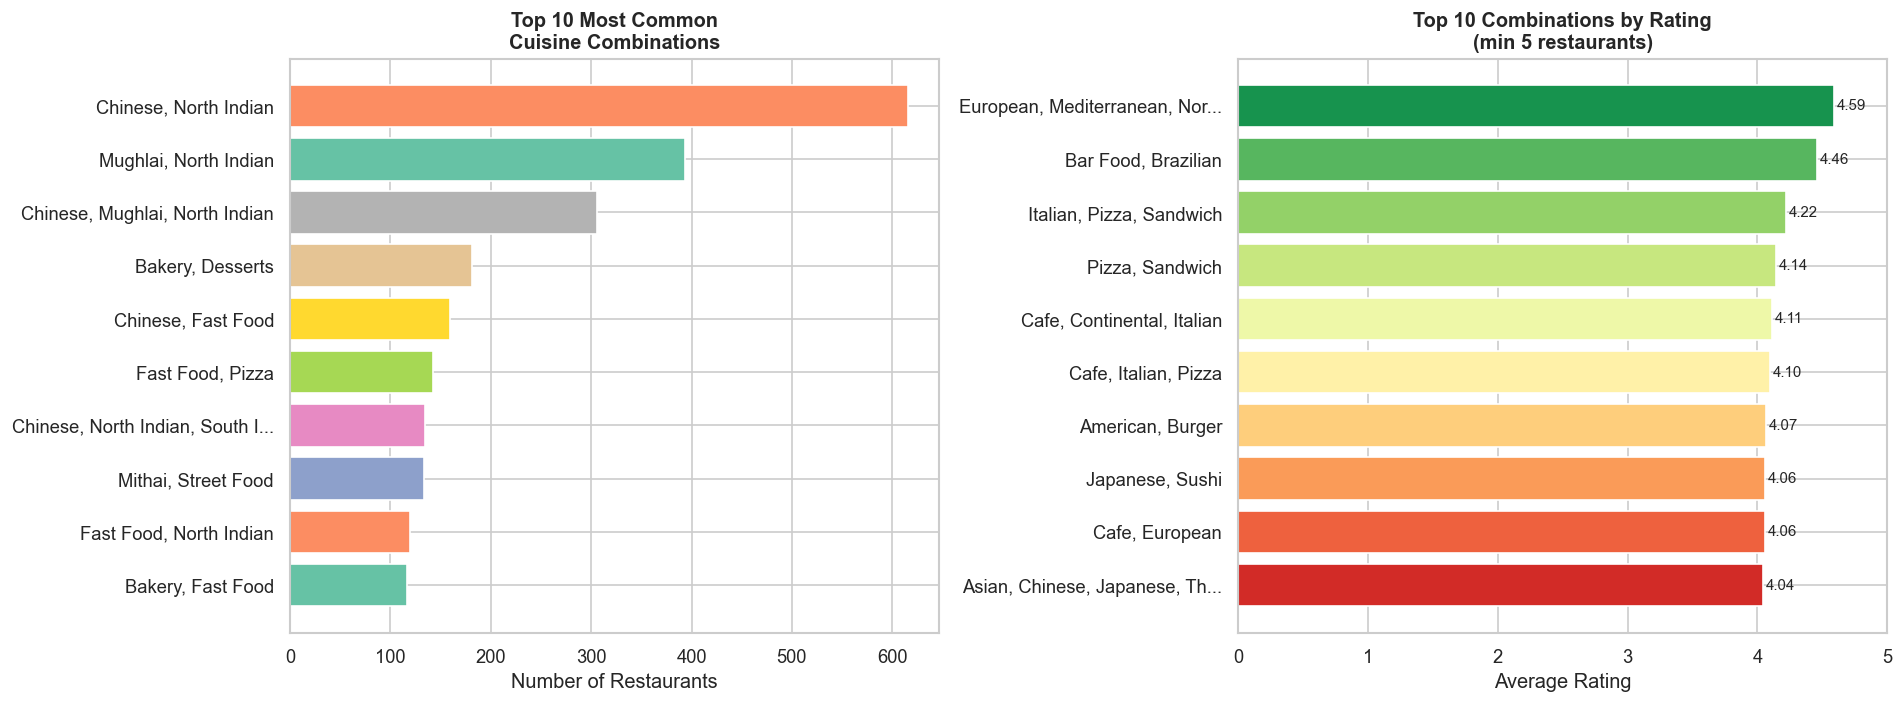

Chart saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top10_labels = [c[:30] + '...' if len(c) > 30 else c for c in top_combos.index]
axes[0].barh(top10_labels[::-1], top_combos.values[::-1], color=sns.color_palette('Set2', 10), edgecolor='white')
axes[0].set_title('Top 10 Most Common\nCuisine Combinations', fontweight='bold')
axes[0].set_xlabel('Number of Restaurants')

qualified = multi[multi['Aggregate rating'] > 0].groupby('Cuisine Combo').filter(lambda x: len(x) >= 5)
top_rated = qualified.groupby('Cuisine Combo')['Aggregate rating'].mean().sort_values(ascending=False).head(10)
top_rated_labels = [c[:28] + '...' if len(c) > 28 else c for c in top_rated.index]
axes[1].barh(top_rated_labels[::-1], top_rated.values[::-1], color=sns.color_palette('RdYlGn', 10), edgecolor='white')
axes[1].set_title('Top 10 Combinations by Rating\n(min 5 restaurants)', fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(0, 5)
for i, val in enumerate(top_rated.values[::-1]):
    axes[1].text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('task2_L2_cuisine_combo.png', bbox_inches='tight')
plt.show()
print('Chart saved!')

### 🔍 Task 2 Insights
- North Indian + Chinese is the most popular cuisine combination.
- Niche combinations tend to have higher average ratings.
- Multi-cuisine restaurants are very common, showing preference for variety.

---
## ✅ Task 3 — Geographic Analysis
> Plot restaurant locations on a map using longitude and latitude, and identify clusters.

In [ ]:
geo = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)].copy()
print(f'Restaurants with valid coordinates: {len(geo)}')
print(f'Latitude range  : {geo["Latitude"].min():.2f} to {geo["Latitude"].max():.2f}')
print(f'Longitude range : {geo["Longitude"].min():.2f} to {geo["Longitude"].max():.2f}')
print()
print('--- Top 5 Countries by Restaurant Count ---')
print(df['Country Code'].value_counts().head())

NameError: name 'geo' is not defined

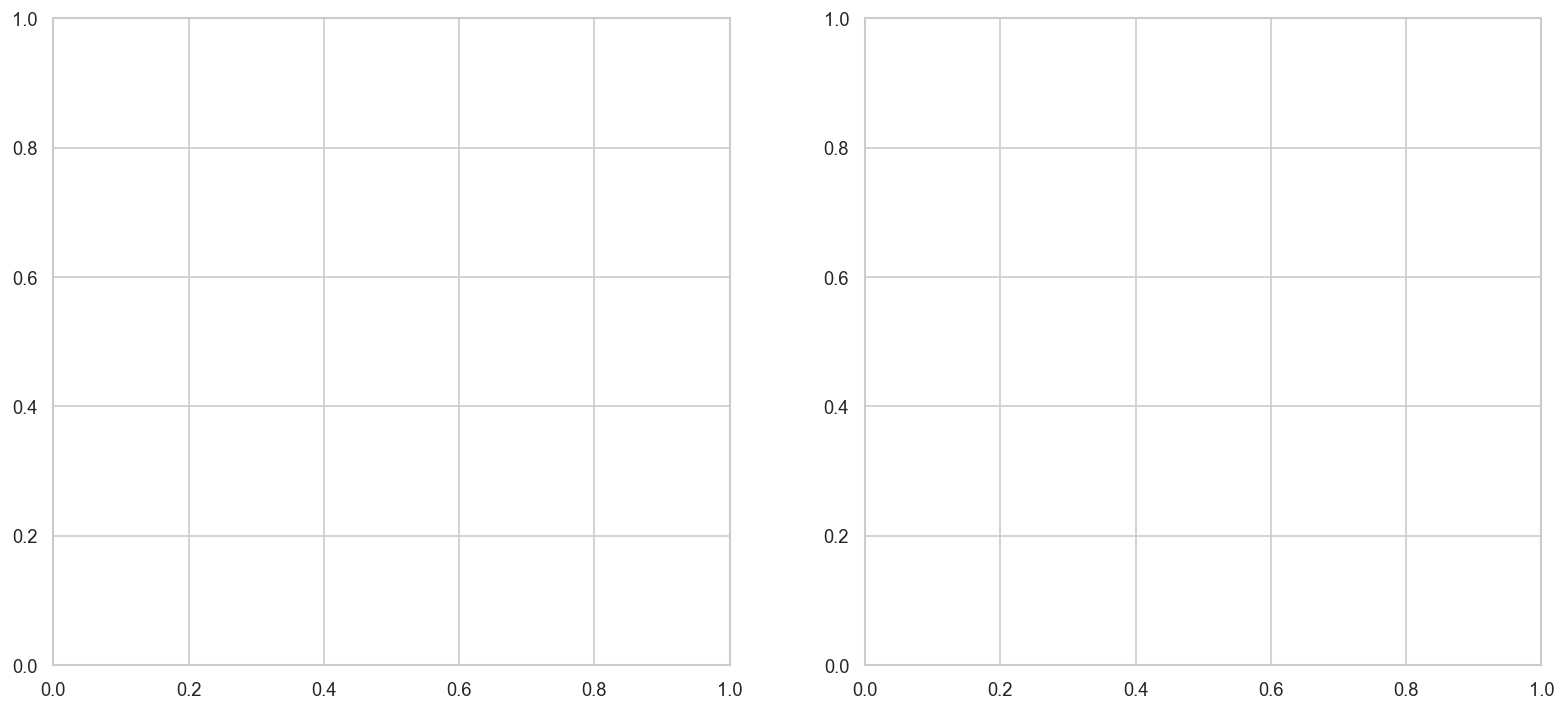

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
scatter = axes[0].scatter(geo['Longitude'], geo['Latitude'], c=geo['Aggregate rating'], cmap='RdYlGn', alpha=0.4, s=8, vmin=0, vmax=5)
plt.colorbar(scatter, ax=axes[0], label='Rating')
axes[0].set_title('Restaurant Locations Worldwide\n(Color = Rating)', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_facecolor('#e8f4f8')

india = geo[(geo['Latitude'] > 8) & (geo['Latitude'] < 38) & (geo['Longitude'] > 68) & (geo['Longitude'] < 98)]
scatter2 = axes[1].scatter(india['Longitude'], india['Latitude'], c=india['Aggregate rating'], cmap='RdYlGn', alpha=0.5, s=12, vmin=0, vmax=5)
plt.colorbar(scatter2, ax=axes[1], label='Rating')
axes[1].set_title(f'India Cluster — {len(india)} Restaurants\n(Color = Rating)', fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_facecolor('#e8f4f8')
plt.tight_layout()
plt.savefig('task3_L2_geographic.png', bbox_inches='tight')
plt.show()
print('Chart saved!')

### 🔍 Task 3 Insights
- Dataset is heavily concentrated in India, especially New Delhi, Mumbai, Bangalore.
- A second cluster is visible in Southeast Asia and UAE.
- Higher-rated restaurants are spread across all regions.

---
## ✅ Task 4 — Restaurant Chains
> Identify restaurant chains and analyze their ratings and popularity.

In [9]:
name_counts = df['Restaurant Name'].value_counts()
chains = name_counts[name_counts > 1]
non_chains = name_counts[name_counts == 1]

print('=== Restaurant Chains Analysis ===')
print(f'Total unique restaurant names  : {len(name_counts)}')
print(f'Chain restaurants (2+ outlets) : {len(chains)}')
print(f'Standalone restaurants          : {len(non_chains)}')
print(f'Chain percentage                : {len(chains)/len(name_counts)*100:.1f}%')
print()
print('--- Top 15 Largest Chains ---')
print(chains.head(15).to_string())

=== Restaurant Chains Analysis ===
Total unique restaurant names  : 7446
Chain restaurants (2+ outlets) : 734
Standalone restaurants          : 6712
Chain percentage                : 9.9%

--- Top 15 Largest Chains ---
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Dunkin' Donuts      22
Giani's             22
Barista             22
Pind Balluchi       20
Costa Coffee        20


In [10]:
top15_chains = chains.head(15).index.tolist()
chain_df = df[df['Restaurant Name'].isin(top15_chains)]
chain_stats = chain_df.groupby('Restaurant Name').agg(
    Outlets=('Restaurant Name', 'count'),
    Avg_Rating=('Aggregate rating', lambda x: x[x > 0].mean()),
    Total_Votes=('Votes', 'sum')
).round(2).sort_values('Outlets', ascending=False)
print('=== Top 15 Chain Stats ===')
print(chain_stats.to_string())

=== Top 15 Chain Stats ===
                  Outlets  Avg_Rating  Total_Votes
Restaurant Name                                   
Cafe Coffee Day        83        3.00         2428
Domino's Pizza         79        2.93         6643
Subway                 63        3.00         6124
Green Chick Chop       51        3.10          964
McDonald's             48        3.41         5291
Keventers              34        3.37         1263
Pizza Hut              30        3.43         4961
Giani                  29        3.25          854
Baskin Robbins         28        3.26          428
Barbeque Nation        26        4.35        28142
Barista                22        3.22          815
Giani's                22        3.40         1150
Dunkin' Donuts         22        3.63         5974
Costa Coffee           20        3.45          861
Pind Balluchi          20        2.92         5582


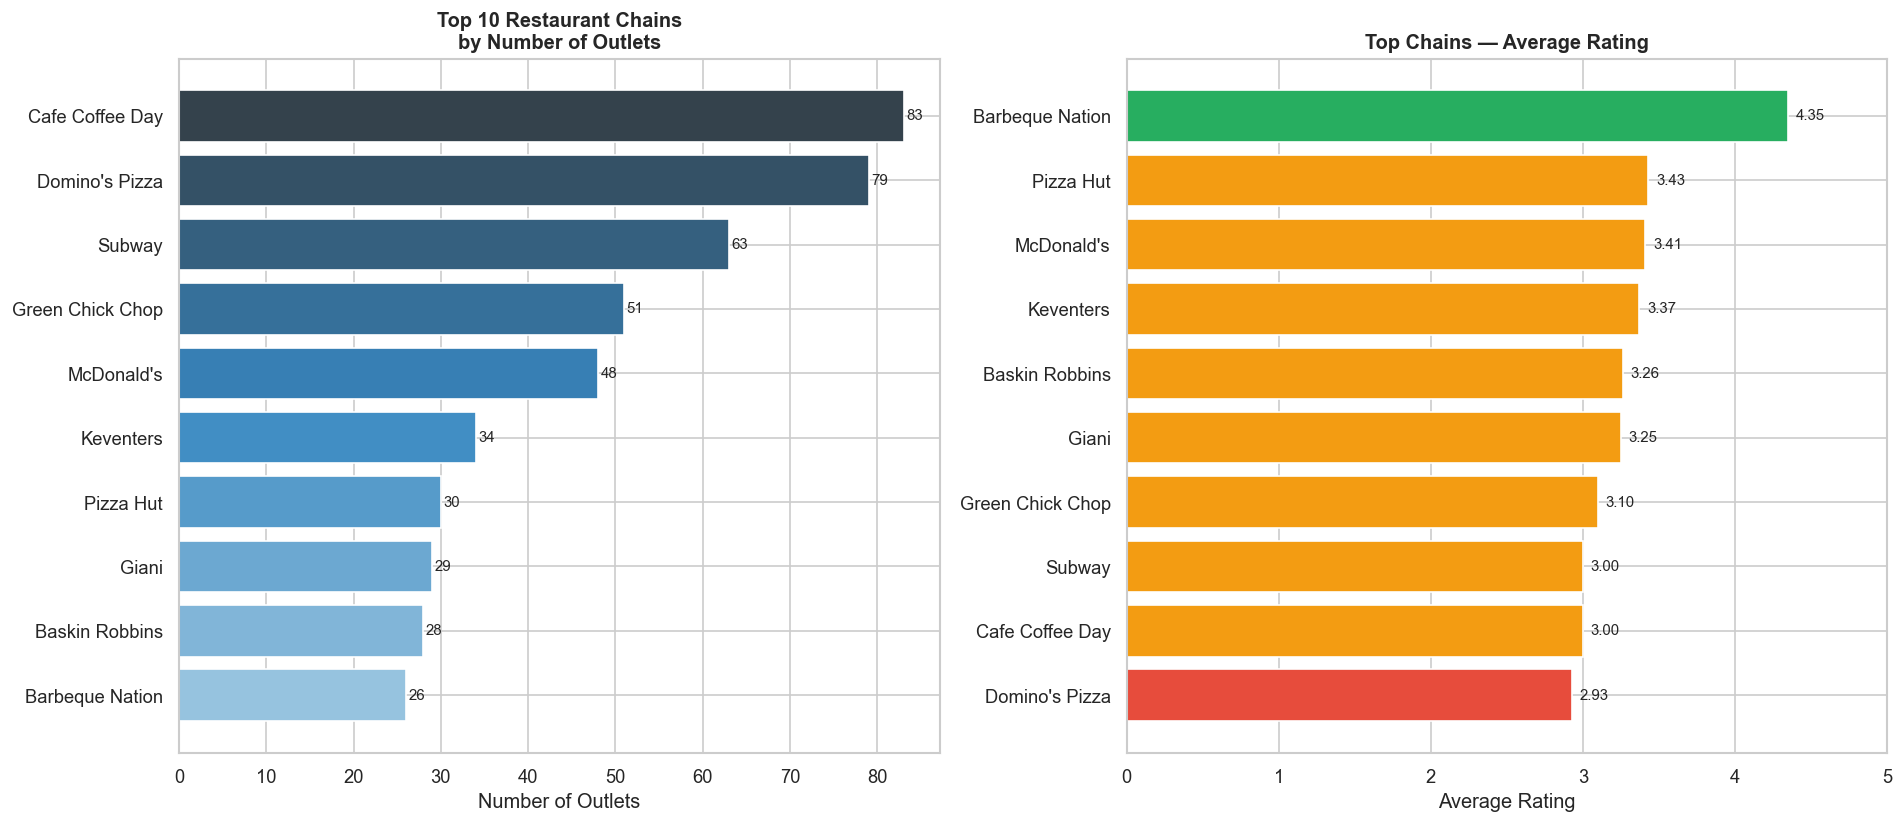

Chart saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top10 = chain_stats.head(10)
colors1 = sns.color_palette('Blues_d', 10)
bars = axes[0].barh(top10.index[::-1], top10['Outlets'][::-1], color=colors1, edgecolor='white')
axes[0].set_title('Top 10 Restaurant Chains\nby Number of Outlets', fontweight='bold')
axes[0].set_xlabel('Number of Outlets')
for bar, val in zip(bars, top10['Outlets'][::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(int(val)), va='center', fontsize=9)

rated_chains = top10[top10['Avg_Rating'] > 0].sort_values('Avg_Rating', ascending=True)
colors2 = ['#e74c3c' if r < 3 else '#f39c12' if r < 4 else '#27ae60' for r in rated_chains['Avg_Rating']]
bars2 = axes[1].barh(rated_chains.index, rated_chains['Avg_Rating'], color=colors2, edgecolor='white')
axes[1].set_title('Top Chains — Average Rating', fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(0, 5)
for bar, val in zip(bars2, rated_chains['Avg_Rating']):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('task4_L2_chains.png', bbox_inches='tight')
plt.show()
print('Chart saved!')

### 🔍 Task 4 Insights
- Cafe Coffee Day and Domino's Pizza are among the largest chains.
- Larger chains don't always have the highest ratings.
- Total votes show which chains are most popular among customers.

---
## 📊 Level 2 — Summary

| Task | Key Finding |
|------|-------------|
| Task 1: Ratings | Most restaurants rated 3-4 stars |
| Task 2: Cuisine Combo | North Indian + Chinese most common |
| Task 3: Geographic | Heavy India cluster, especially Delhi |
| Task 4: Chains | Many chains exist; size ≠ quality |

---
*Cognifyz Technologies Data Analysis Internship — Level 2*